In [393]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# fs = 100
# dt = 1 / fs


In [394]:
df_cuat = pd.read_csv(r"21_05_2026\02\results_4\quaternionfilter_4_sinc.csv")

df_imu = pd.read_csv(r"21_05_2026\02\results_4\sensordata_4.csv")

start_time_hhmmss = '16:19:20.26'

zupt_periods_hhmmss = [
    ("16:19:20.26", "16:19:38.00"),
    ("16:20:15.00", "16:20:35.00"),
    ("16:21:05.00", "16:21:33.67"),
]

In [395]:
df_cuat

,unix_time_ms,fGPS_ts_tow,fGPS_valid,estQ0,estQ1,estQ2,estQ3,estQ_valid,flag
0,1779393654774,417672.774,3,0.999110,0.012424,0.040165,-0.003462,1,0
1,1779393654784,417672.784,3,0.999111,0.012426,0.040147,-0.003460,1,0
2,1779393654804,417672.804,3,0.999112,0.012592,0.040063,-0.003470,1,0
3,1779393654814,417672.814,3,0.999111,0.012522,0.040108,-0.003470,1,0
4,1779393654834,417672.834,3,0.999111,0.012372,0.040164,-0.003464,1,0
...,...,...,...,...,...,...,...,...,...
4517,1779393719844,417737.844,3,0.016984,-0.027253,-0.007721,0.999454,1,1
4518,1779393719864,417737.864,3,0.016902,-0.027813,-0.008041,0.999438,1,1
4519,1779393719874,417737.874,3,0.016900,-0.027837,-0.007901,0.999438,1,1
4520,1779393719894,417737.894,3,0.016846,-0.028294,-0.008060,0.999425,1,1


In [396]:
# Renombrar columnas
cuat_new_names = ["q0", "q1", "q2", "q3", "zupt_flag"]
df_cuat = df_cuat.rename(columns=dict(zip(df_cuat.columns[3:7], cuat_new_names[:4])))

# df_cuat = df_cuat.rename(columns=dict(zip(df_cuat.columns[-1], cuat_new_names[-1])))
df_cuat = df_cuat.rename(columns={df_cuat.columns[-1]: cuat_new_names[-1]})

df_cuat = df_cuat.sort_values("fGPS_ts_tow").reset_index(drop=True)

df_cuat["Time"] = pd.to_numeric(df_cuat["unix_time_ms"]).round().astype("Int64")

df_cuat["timestamp"] = pd.to_datetime(df_cuat["Time"], unit="ms")

# Tiempo relativo en segundos
df_cuat["t"] = (df_cuat["fGPS_ts_tow"] - df_cuat["fGPS_ts_tow"].iloc[0])

# Delta de tiempo entre muestra
df_cuat["dt"] = df_cuat["t"].diff()

df_cuat.rename(columns={"fGPS_ts_tow": "fGPS_ts"}, inplace=True)

# Reordenar columnas
df_cuat = df_cuat.reindex(columns=['Time', 'fGPS_ts', 'timestamp', 't', 'dt', 'q0', 'q1', 'q2', 'q3' ,'zupt_flag'])

print(df_cuat["Time"].iloc[0])

df_cuat

1779393654774


,Time,fGPS_ts,timestamp,t,dt,q0,q1,q2,q3,zupt_flag
0,1779393654774,417672.774,2026-05-21 20:00:54.774,0.00,NaN,0.999110,0.012424,0.040165,-0.003462,0
1,1779393654784,417672.784,2026-05-21 20:00:54.784,0.01,0.01,0.999111,0.012426,0.040147,-0.003460,0
2,1779393654804,417672.804,2026-05-21 20:00:54.804,0.03,0.02,0.999112,0.012592,0.040063,-0.003470,0
3,1779393654814,417672.814,2026-05-21 20:00:54.814,0.04,0.01,0.999111,0.012522,0.040108,-0.003470,0
4,1779393654834,417672.834,2026-05-21 20:00:54.834,0.06,0.02,0.999111,0.012372,0.040164,-0.003464,0
...,...,...,...,...,...,...,...,...,...,...
4517,1779393719844,417737.844,2026-05-21 20:01:59.844,65.07,0.01,0.016984,-0.027253,-0.007721,0.999454,1
4518,1779393719864,417737.864,2026-05-21 20:01:59.864,65.09,0.02,0.016902,-0.027813,-0.008041,0.999438,1
4519,1779393719874,417737.874,2026-05-21 20:01:59.874,65.10,0.01,0.016900,-0.027837,-0.007901,0.999438,1
4520,1779393719894,417737.894,2026-05-21 20:01:59.894,65.12,0.02,0.016846,-0.028294,-0.008060,0.999425,1


In [397]:
list(df_imu.columns.values)

['unix_time_ms',
 'GPS_ts_tow',
 'scaledAccelX',
 'scaledAccelY',
 'scaledAccelZ',
 'deltaVelX',
 'deltaVelY',
 'deltaVelZ',
 'estLinAccelX',
 'estLinAccelY',
 'estLinAccelZ',
 'estLinAccel_valid',
 'estAngRateX',
 'estAngRateY',
 'estAngRateZ',
 'estAngRate_valid',
 'estGravityX',
 'estGravityY',
 'estGravityZ',
 'estGravity_valid',
 'flag']

In [398]:
al_new_names = ["alx", "aly", "alz"]

df_imu = df_imu.rename(columns=dict(zip(df_imu.columns[8:12], al_new_names)))

df_imu["Time"] = pd.to_numeric(df_imu["unix_time_ms"]).round().astype("Int64")

df_imu.rename(columns={"GPS_ts_tow": "fGPS_ts"}, inplace=True)

df_imu = df_imu.reindex(columns=["Time", "fGPS_ts", "alx", "aly", "alz"])
# df_imu = df_imu.sort_values("fGPS_ts").reset_index(drop=True)

df_imu

,Time,fGPS_ts,alx,aly,alz
0,1779393654774,417672.774,-0.041841,0.063627,0.088118
1,1779393654784,417672.784,-0.049279,0.055981,0.065052
2,1779393654804,417672.804,0.062520,-0.096436,-0.026647
3,1779393654814,417672.814,0.020781,-0.028817,-0.004277
4,1779393654834,417672.834,-0.046315,0.076538,0.058010
...,...,...,...,...,...
57334,1779394482024,418500.024,-0.028264,-0.142445,0.069075
57335,1779394482034,418500.034,-0.037539,-0.139231,0.119796
57336,1779394482044,418500.044,-0.065700,-0.119762,0.105539
57337,1779394482064,418500.064,-0.049398,-0.099381,0.036177


In [399]:
tol_s = 0.005  # 5 ms

df_u = pd.merge_asof(
    df_cuat,
    df_imu,
    on="fGPS_ts",
    direction="nearest",
    tolerance=tol_s
)

# Eliminar filas donde no hubo coincidencia dentro de la tolerancia
df_u = df_u.dropna(
    subset=["alx", "aly", "alz"]
).reset_index(drop=True)

df_u

,Time_x,fGPS_ts,timestamp,t,dt,q0,q1,q2,q3,zupt_flag,Time_y,alx,aly,alz
0,1779393654774,417672.774,2026-05-21 20:00:54.774,0.00,NaN,0.999110,0.012424,0.040165,-0.003462,0,1779393654774,-0.041841,0.063627,0.088118
1,1779393654784,417672.784,2026-05-21 20:00:54.784,0.01,0.01,0.999111,0.012426,0.040147,-0.003460,0,1779393654784,-0.049279,0.055981,0.065052
2,1779393654804,417672.804,2026-05-21 20:00:54.804,0.03,0.02,0.999112,0.012592,0.040063,-0.003470,0,1779393654804,0.062520,-0.096436,-0.026647
3,1779393654814,417672.814,2026-05-21 20:00:54.814,0.04,0.01,0.999111,0.012522,0.040108,-0.003470,0,1779393654814,0.020781,-0.028817,-0.004277
4,1779393654834,417672.834,2026-05-21 20:00:54.834,0.06,0.02,0.999111,0.012372,0.040164,-0.003464,0,1779393654834,-0.046315,0.076538,0.058010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4517,1779393719844,417737.844,2026-05-21 20:01:59.844,65.07,0.01,0.016984,-0.027253,-0.007721,0.999454,1,1779393719844,0.810879,0.230085,-0.368767
4518,1779393719864,417737.864,2026-05-21 20:01:59.864,65.09,0.02,0.016902,-0.027813,-0.008041,0.999438,1,1779393719864,-0.108170,0.084367,0.769998
4519,1779393719874,417737.874,2026-05-21 20:01:59.874,65.10,0.01,0.016900,-0.027837,-0.007901,0.999438,1,1779393719874,0.129951,0.020544,0.357050
4520,1779393719894,417737.894,2026-05-21 20:01:59.894,65.12,0.02,0.016846,-0.028294,-0.008060,0.999425,1,1779393719894,0.371953,0.394858,0.863716


In [400]:
# Validación

print(df_u["dt"].describe())

fs_mean = 1 / df_u["dt"].iloc[1:].mean()
print(f"Frecuencia promedio: {fs_mean:.2f} Hz")

count    4521.000000
mean        0.014411
std         0.005067
min         0.010000
25%         0.010000
50%         0.010000
75%         0.020000
max         0.030000
Name: dt, dtype: float64
Frecuencia promedio: 69.39 Hz


In [401]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R


def ins_strapdown_dead_reckoning(
    df, acc_cols=("alx", "aly", "alz"), quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t", dt_col="dt", zupt_flag_col="zupt_flag",
    G_acc=1.0, p_gain=1.0, ZUPT_GAIN=1.0, hard_zupt=True,
    use_nhc=True, K_nhc_y=0.9, K_nhc_z=0.9,
    use_transpose=True, normalize_quat=True, verbose=True,
):
    df_out = df.copy()
    required_cols = list(acc_cols) + list(quat_cols) + [time_col, dt_col, zupt_flag_col]
    missing = [c for c in required_cols if c not in df_out.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    # ---- 1. Todo a numpy de una sola vez ----
    num = df_out[required_cols].apply(pd.to_numeric, errors="coerce")
    acc = num[list(acc_cols)].to_numpy(float)          # (N,3)
    quat = num[list(quat_cols)].to_numpy(float)        # (N,4) -> q0..q3
    t_arr = num[time_col].to_numpy(float)
    dt_arr = num[dt_col].to_numpy(float)
    zupt = np.nan_to_num(num[zupt_flag_col].to_numpy(float), nan=0.0).astype(int)
    N = len(df_out)

    # ---- 2. Matrices de rotación vectorizadas ----
    q_norm = np.linalg.norm(quat, axis=1)
    valid_q = (q_norm > 0) & ~np.isnan(quat).any(axis=1)
    q_unit = quat.copy()
    if normalize_quat:
        q_unit[valid_q] = quat[valid_q] / q_norm[valid_q, None]

    R_all = np.full((N, 3, 3), np.nan)
    if valid_q.any():
        # scipy usa [x,y,z,w] = [q1,q2,q3,q0]
        mats = R.from_quat(q_unit[valid_q][:, [1, 2, 3, 0]]).as_matrix()
        if use_transpose:
            mats = np.transpose(mats, (0, 2, 1))
        R_all[valid_q] = mats

    # ---- 3. a_nav vectorizado ----
    valid_acc = ~np.isnan(acc).any(axis=1)
    valid_row = valid_q & valid_acc
    a_nav_all = np.full((N, 3), np.nan)
    a_nav_all[valid_row] = G_acc * np.einsum("nij,nj->ni", R_all[valid_row], acc[valid_row])

    # Filas que el original procesa (no hace 'continue')
    processable = valid_row & ~np.isnan(t_arr) & ~np.isnan(dt_arr) & (dt_arr > 0)

    # ---- 4. Buffers de salida ----
    A_nav = np.full((N, 3), np.nan)
    A_body_nhc = np.full((N, 3), np.nan)
    A_nav_nhc = np.full((N, 3), np.nan)
    V_int = np.full((N, 3), np.nan)
    Vb_raw = np.full((N, 3), np.nan)
    Vb_nhc = np.full((N, 3), np.nan)
    Vel = np.full((N, 3), np.nan)
    Pos = np.full((N, 3), np.nan)
    Pos_scale = np.full((N, 3), np.nan)

    # ---- 5. Loop secuencial mínimo (solo numpy) ----
    p = np.zeros(3)
    v = np.zeros(3)
    a_nav_prev = None
    ky, kz = 1.0 - K_nhc_y, 1.0 - K_nhc_z

    for k in range(N):
        if not processable[k]:
            Vel[k] = v
            Pos[k] = p
            Pos_scale[k] = p_gain * p
            continue

        a_nav = a_nav_all[k]
        R_nb = R_all[k]
        dt = dt_arr[k]
        A_nav[k] = a_nav

        v_prev = v.copy()
        if a_nav_prev is None:
            a_nav_prev = a_nav.copy()
        v = v + 0.5 * (a_nav_prev + a_nav) * dt
        V_int[k] = v

        if zupt[k] == 0:
            if hard_zupt:
                v = np.zeros(3)
            else:
                v = v - ZUPT_GAIN * v

        if use_nhc:
            v_body = R_nb.T @ v
            Vb_raw[k] = v_body
            v_body = v_body * np.array([1.0, ky, kz])
            Vb_nhc[k] = v_body
            v = R_nb @ v_body

            a_body_nhc = acc[k] * np.array([1.0, ky, kz])
            A_body_nhc[k] = a_body_nhc
            A_nav_nhc[k] = R_nb @ a_body_nhc

        p = p + 0.5 * (v_prev + v) * dt
        a_nav_prev = a_nav.copy()
        Vel[k] = v
        Pos[k] = p
        Pos_scale[k] = p_gain * p

    # ---- 6. Volcar todo al DataFrame de una vez ----
    df_out[["a_nav_x", "a_nav_y", "a_nav_z"]] = A_nav
    df_out[["a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc"]] = A_body_nhc
    df_out[["a_nav_x_nhc", "a_nav_y_nhc", "a_nav_z_nhc"]] = A_nav_nhc
    df_out[["v_int_x", "v_int_y", "v_int_z"]] = V_int
    df_out[["vx_body_raw", "vy_body_raw", "vz_body_raw"]] = Vb_raw
    df_out[["vx_body_nhc", "vy_body_nhc", "vz_body_nhc"]] = Vb_nhc
    df_out[["vx", "vy", "vz"]] = Vel
    df_out[["px", "py", "pz"]] = Pos
    df_out[["px_scale", "py_scale", "pz_scale"]] = Pos_scale
    df_out["zupt_applied"] = zupt

    if verbose:
        print("INS strapdown finalizado.")
        print(f"Filas procesadas: {N}")
        print(f"Posicion final [m]: {p}")
        print(f"Velocidad final [m/s]: {v}")
        print(f"Muestras con ZUPT aplicado: {int(zupt.sum())}")

    return df_out

In [402]:
import pandas as pd
import numpy as np


def hhmmss_to_seconds(hhmmss):
    """
    Convierte una hora tipo:
        '16:46:25.77'
        '16:47:00.7'
        '16:47:27'
    a segundos desde las 00:00:00.
    """

    parts = hhmmss.strip().split(":")

    if len(parts) != 3:
        raise ValueError(f"Formato inválido: {hhmmss}. Usa HH:MM:SS.sss")

    h = int(parts[0])
    m = int(parts[1])
    s = float(parts[2])

    return h * 3600 + m * 60 + s


def convert_zupt_periods_hhmmss_to_relative(zupt_periods_hhmmss, start_time_hhmmss):
    """
    Convierte periodos ZUPT dados en hora real HH:MM:SS.sss
    a periodos relativos en segundos respecto a start_time_hhmmss.

    Ejemplo:
        start_time_hhmmss = '16:46:09.77'

        zupt_periods_hhmmss = [
            ('16:46:25.77', '16:46:30.25'),
            ('16:46:52.64', '16:47:00.7')
        ]

    Retorna:
        [
            (16.0, 20.48),
            (42.87, 50.93)
        ]
    """

    t0_abs = hhmmss_to_seconds(start_time_hhmmss)

    zupt_periods_rel = []

    for t_ini_str, t_fin_str in zupt_periods_hhmmss:
        t_ini_abs = hhmmss_to_seconds(t_ini_str)
        t_fin_abs = hhmmss_to_seconds(t_fin_str)

        t_ini_rel = t_ini_abs - t0_abs
        t_fin_rel = t_fin_abs - t0_abs

        if t_fin_rel < t_ini_rel:
            raise ValueError(
                f"Periodo inválido: {t_ini_str} - {t_fin_str}. "
                "El tiempo final es menor que el inicial."
            )

        zupt_periods_rel.append((t_ini_rel, t_fin_rel))

    return zupt_periods_rel

In [403]:
# Hora de inicio = primer timestamp de la data (corresponde a t = 0)
# Se deriva del primer registro de df_cuat y se ajusta a hora local Lima (UTC-5).
# Si tus periodos ZUPT no calzan, define start_time_hhmmss manualmente.
start_time_hhmmss = (
    df_cuat["timestamp"].iloc[0] - pd.Timedelta(hours=5)
).strftime("%H:%M:%S.%f")[:-4]

print("start_time_hhmmss =", start_time_hhmmss)

zupt_periods = convert_zupt_periods_hhmmss_to_relative(
    zupt_periods_hhmmss,
    start_time_hhmmss
)

print(zupt_periods)

start_time_hhmmss = 15:00:54.77
[(4705.490000000005, 4723.230000000003), (4760.230000000003, 4780.230000000003), (4810.230000000003, 4838.9000000000015)]


In [404]:
# # Periodos donde sabes que el vehículo está detenido

# zupt_periods = [
#     #  t_inicio, t_final
#     (0, 18),    # detenido al inicio
#     (55, 75),
#     (105, 133),  # detenido al final
# ]

In [405]:
df_ins = ins_strapdown_dead_reckoning(
    df=df_u,
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t",
    dt_col="dt",

    G_acc=1.0,
    p_gain=1.0,

    # zupt_periods=zupt_periods,
    ZUPT_GAIN=1.0,
    hard_zupt=True,

    use_nhc=True,
    K_nhc_y=0.9,
    K_nhc_z=0.9,

    use_transpose=True
)

df_ins.head()

INS strapdown finalizado.
Filas procesadas: 4522
Posicion final [m]: [65.63196225 67.93213457 10.04790292]
Velocidad final [m/s]: [-8.54001326 -0.28519774 -0.4869329 ]
Muestras con ZUPT aplicado: 4203


,Time_x,fGPS_ts,timestamp,t,dt,q0,q1,q2,q3,zupt_flag,...,vx,vy,vz,px,py,pz,px_scale,py_scale,pz_scale,zupt_applied
0,1779393654774,417672.774,2026-05-21 20:00:54.774,0.00,NaN,0.999110,0.012424,0.040165,-0.003462,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1779393654784,417672.784,2026-05-21 20:00:54.784,0.01,0.01,0.999111,0.012426,0.040147,-0.003460,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,1779393654804,417672.804,2026-05-21 20:00:54.804,0.03,0.02,0.999112,0.012592,0.040063,-0.003470,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1779393654814,417672.814,2026-05-21 20:00:54.814,0.04,0.01,0.999111,0.012522,0.040108,-0.003470,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,1779393654834,417672.834,2026-05-21 20:00:54.834,0.06,0.02,0.999111,0.012372,0.040164,-0.003464,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [406]:
df_ins.head

<bound method NDFrame.head of              Time_x     fGPS_ts               timestamp      t    dt  \
0     1779393654774  417672.774 2026-05-21 20:00:54.774   0.00   NaN   
1     1779393654784  417672.784 2026-05-21 20:00:54.784   0.01  0.01   
2     1779393654804  417672.804 2026-05-21 20:00:54.804   0.03  0.02   
3     1779393654814  417672.814 2026-05-21 20:00:54.814   0.04  0.01   
4     1779393654834  417672.834 2026-05-21 20:00:54.834   0.06  0.02   
...             ...         ...                     ...    ...   ...   
4517  1779393719844  417737.844 2026-05-21 20:01:59.844  65.07  0.01   
4518  1779393719864  417737.864 2026-05-21 20:01:59.864  65.09  0.02   
4519  1779393719874  417737.874 2026-05-21 20:01:59.874  65.10  0.01   
4520  1779393719894  417737.894 2026-05-21 20:01:59.894  65.12  0.02   
4521  1779393719924  417737.924 2026-05-21 20:01:59.924  65.15  0.03   

            q0        q1        q2        q3  zupt_flag  ...        vx  \
0     0.999110  0.012424  0.040

In [407]:
# v_cols=("vx_body_raw", "vy_body_raw", "vz_body_raw")

# v_body = df_ins.loc[2000, list(v_cols)].to_numpy(dtype=float)

# # df_u.loc[2000, ["vx_body_raw", "vy_body_raw", "vz_body_raw"]] = v_body

# print(v_body)
# print(v_body.shape)


# # Restricción no holonómica:
# # vehículo no debería desplazarse lateral ni verticalmente
# # v_body[1] = v_body[1] * (1.0 - K_nhc_y)
# # v_body[2] = v_body[2] * (1.0 - K_nhc_z)
# B = np.array([1, 0, 0])
# print(B)
# print(B.shape)
# v_body = v_body * B
# print(v_body)

In [408]:
df_ins.to_csv(r'21_05_2026\prueba_08_imu.csv', index=False)
df_ins

,Time_x,fGPS_ts,timestamp,t,dt,q0,q1,q2,q3,zupt_flag,...,vx,vy,vz,px,py,pz,px_scale,py_scale,pz_scale,zupt_applied
0,1779393654774,417672.774,2026-05-21 20:00:54.774,0.00,NaN,0.999110,0.012424,0.040165,-0.003462,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
1,1779393654784,417672.784,2026-05-21 20:00:54.784,0.01,0.01,0.999111,0.012426,0.040147,-0.003460,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
2,1779393654804,417672.804,2026-05-21 20:00:54.804,0.03,0.02,0.999112,0.012592,0.040063,-0.003470,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
3,1779393654814,417672.814,2026-05-21 20:00:54.814,0.04,0.01,0.999111,0.012522,0.040108,-0.003470,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
4,1779393654834,417672.834,2026-05-21 20:00:54.834,0.06,0.02,0.999111,0.012372,0.040164,-0.003464,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4517,1779393719844,417737.844,2026-05-21 20:01:59.844,65.07,0.01,0.016984,-0.027253,-0.007721,0.999454,1,...,-8.520895,-0.286253,-0.466776,66.314400,67.954945,10.086266,66.314400,67.954945,10.086266,1
4518,1779393719864,417737.864,2026-05-21 20:01:59.864,65.09,0.02,0.016902,-0.027813,-0.008041,0.999438,1,...,-8.527454,-0.285373,-0.475990,66.143917,67.949229,10.076839,66.143917,67.949229,10.076839,1
4519,1779393719874,417737.874,2026-05-21 20:01:59.874,65.10,0.01,0.016900,-0.027837,-0.007901,0.999438,1,...,-8.527516,-0.285022,-0.477048,66.058642,67.946377,10.072073,66.058642,67.946377,10.072073,1
4520,1779393719894,417737.894,2026-05-21 20:01:59.894,65.12,0.02,0.016846,-0.028294,-0.008060,0.999425,1,...,-8.532170,-0.284578,-0.483844,65.888045,67.940681,10.062465,65.888045,67.940681,10.062465,1


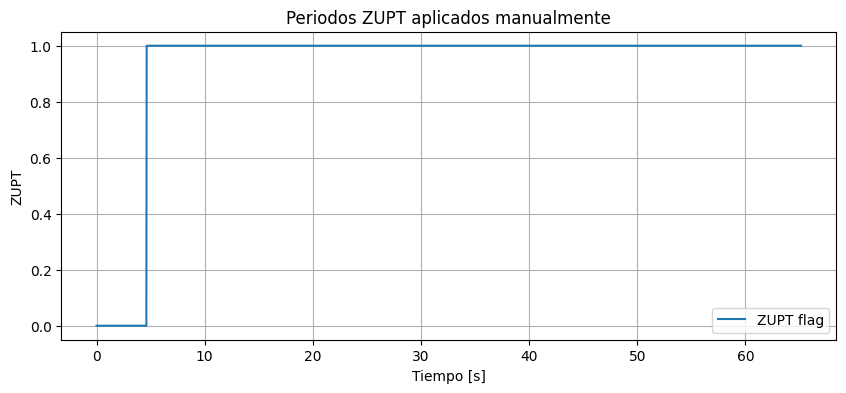

In [409]:
plt.figure(figsize=(10, 4))
plt.plot(df_ins["t"], df_ins["zupt_flag"], label="ZUPT flag")
plt.xlabel("Tiempo [s]")
plt.ylabel("ZUPT")
plt.title("Periodos ZUPT aplicados manualmente")
plt.grid(True)
plt.legend()
plt.show()

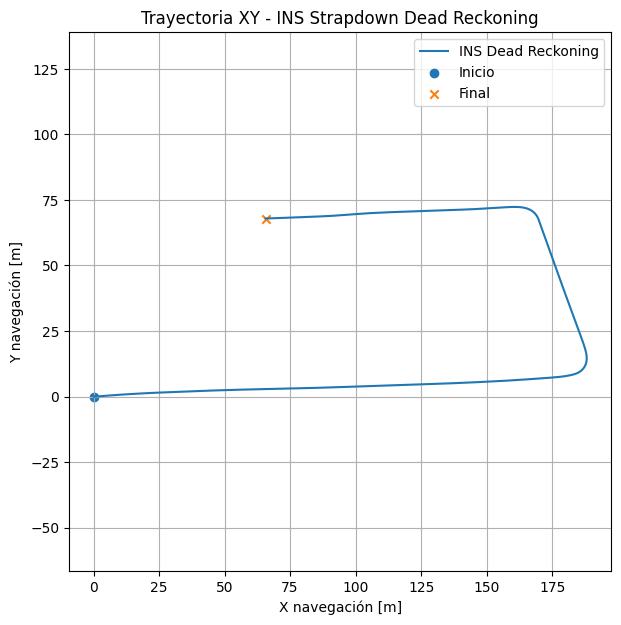

In [410]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.plot(df_ins["px"], df_ins["py"], label="INS Dead Reckoning")

plt.scatter(df_ins["px"].iloc[0], df_ins["py"].iloc[0], label="Inicio", marker="o")
plt.scatter(df_ins["px"].iloc[-1], df_ins["py"].iloc[-1], label="Final", marker="x")

plt.xlabel("X navegación [m]")
plt.ylabel("Y navegación [m]")
plt.title("Trayectoria XY - INS Strapdown Dead Reckoning")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

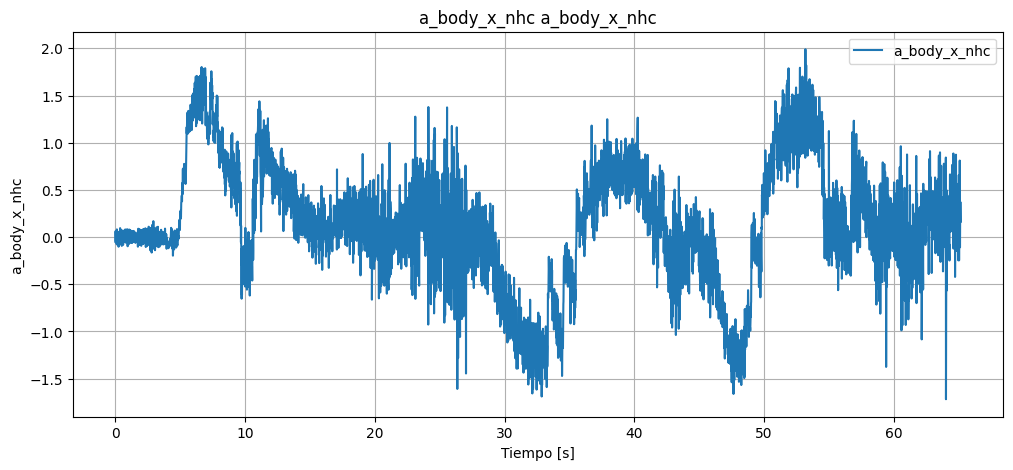

In [411]:
# for col in ["a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc"]:
col = "a_body_x_nhc"
plt.figure(figsize=(12, 5))
plt.plot(df_ins["t"], df_ins[col], label=col)
plt.xlabel("Tiempo [s]")
plt.ylabel("a_body_x_nhc")
plt.title(f"a_body_x_nhc {col}")
plt.legend()
plt.grid(True)
plt.show()

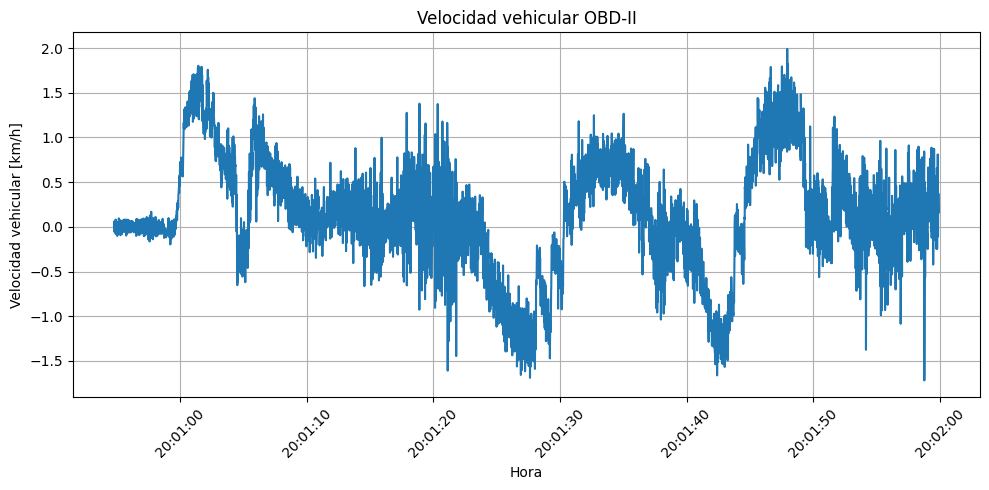

In [412]:
plt.figure(figsize=(10, 5))
plt.plot(df_ins["timestamp"], df_ins["a_body_x_nhc"])
plt.xlabel("Hora")
plt.ylabel("Velocidad vehicular [km/h]")
plt.title("Velocidad vehicular OBD-II")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

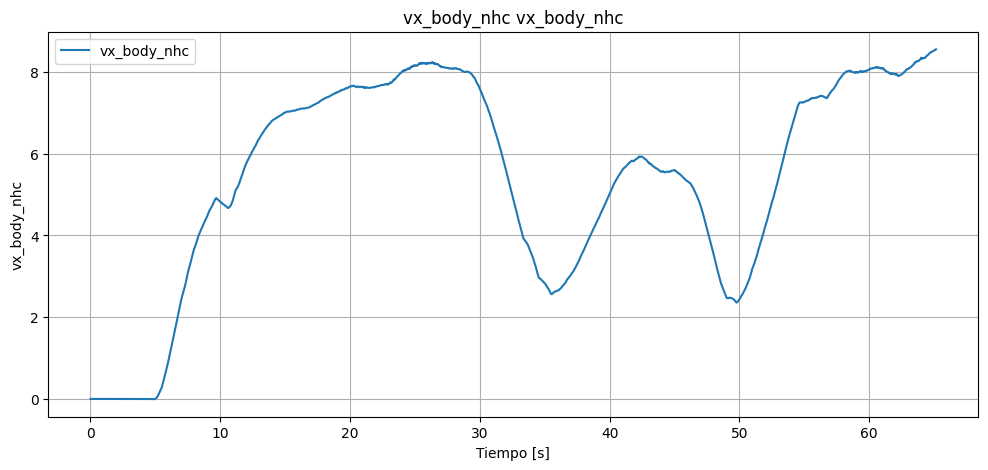

In [413]:
# for col in ["vx_body_nhc", "vy_body_nhc", "vz_body_nhc"]:
col = "vx_body_nhc"
plt.figure(figsize=(12, 5))
plt.plot(df_ins["t"], df_ins[col], label=col)
plt.xlabel("Tiempo [s]")
plt.ylabel("vx_body_nhc")
plt.title(f"vx_body_nhc {col}")
plt.legend()
plt.grid(True)
plt.show()


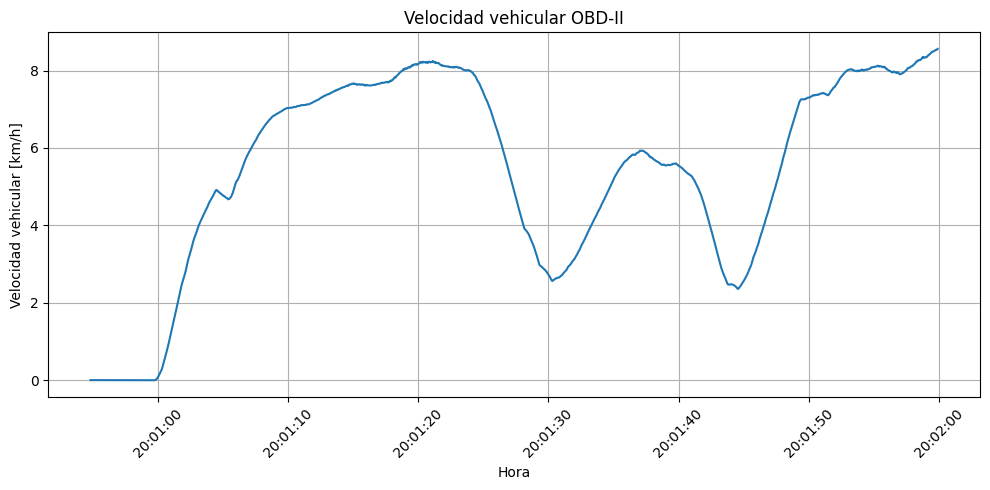

In [414]:
plt.figure(figsize=(10, 5))
plt.plot(df_ins["timestamp"], df_ins["vx_body_nhc"])
plt.xlabel("Hora")
plt.ylabel("Velocidad vehicular [km/h]")
plt.title("Velocidad vehicular OBD-II")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

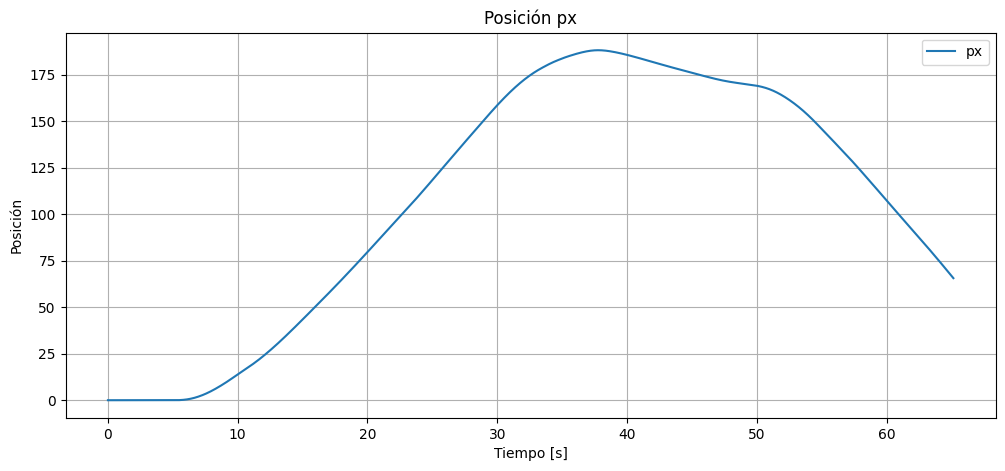

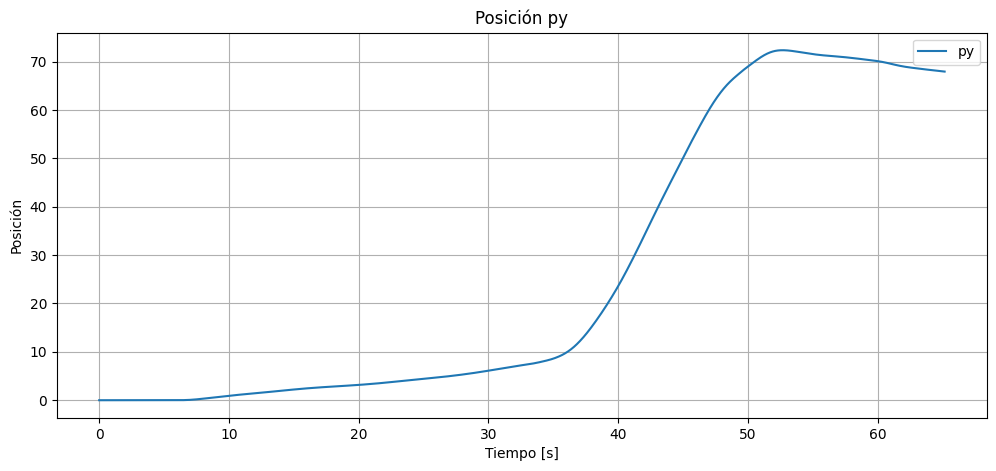

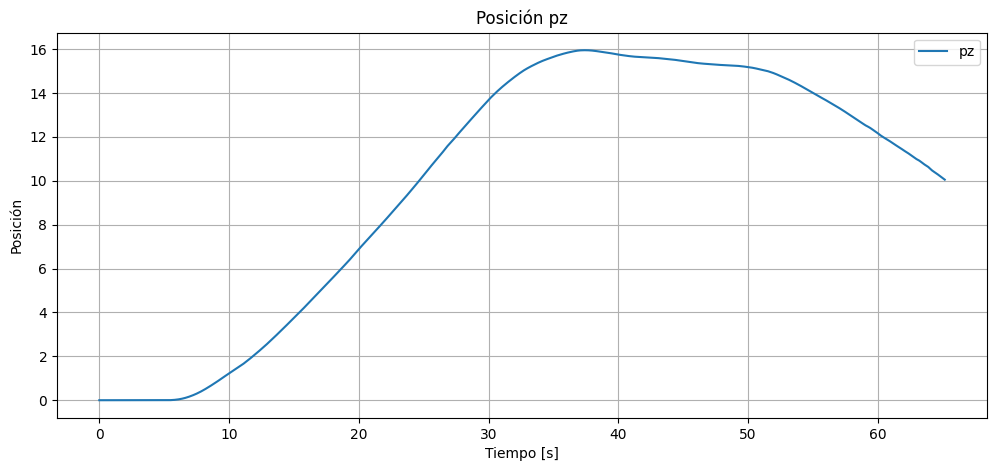

In [415]:
for col in ["px", "py", "pz"]:
    plt.figure(figsize=(12, 5))
    plt.plot(df_ins["t"], df_ins[col], label=col)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Posición")
    plt.title(f"Posición {col}")
    plt.legend()
    plt.grid(True)
    plt.show()